# UNet Semantic Segmentation of Small Water Bodies — Google Colab
### Using the Mukherjee et al. (2024) PlanetScope Validation Dataset

**Dataset:** [Mukherjee et al. 2024](https://doi.org/10.25739/03nt-4f29)  
**Reference:** Mukherjee R. et al., *Earth Syst. Sci. Data*, 16, 4311–4323, 2024

---

## Colab Setup Notes

**Runtime:** Before running, select **Runtime → Change runtime type → T4 GPU** (free tier) or A100 (Colab Pro).  
**Session limits:** Free Colab sessions disconnect after ~12 hours of inactivity. Checkpoints are saved to Google Drive after every epoch so training can be resumed.
**Connecting from VSCode:** See Section 0.1.

**Expected data layout on Google Drive:**
```
MyDrive/
  Research/
    EO-Methane/
     paper2/
      data/
        Mukherjee_2024/
          PS/          ← 10-band preprocessed PlanetScope GeoTIFFs
          labels/      ← binary water mask GeoTIFFs
          slope/       ← optional DEM-derived rasters
          hillshade/   ← optional DEM-derived rasters
      checkpoints/     ← created automatically
```

---

## Band Definitions

| Band | Index (0-based) | Name         | Formula / Source |
|------|-----------------|--------------|------------------|
| b1   | 0               | coastal_blue | SuperDove coastal blue |
| b2   | 1               | blue         | SuperDove blue |
| b3   | 2               | green        | SuperDove green |
| b4   | 3               | red          | SuperDove red |
| b5   | 4               | rededge      | SuperDove red edge |
| b6   | 5               | nir          | SuperDove NIR |
| b7   | 6               | ndvi         | (NIR − RED) / (NIR + RED) |
| b8   | 7               | ndwi         | (GREEN − NIR) / (GREEN + NIR) |
| b9   | 8               | ndre         | (NIR − RedEdge) / (NIR + RedEdge) |
| b10  | 9               | nisi         | ((BLUE + GREEN + RED) − NIR) / ((BLUE + GREEN + RED) + NIR) |

**Visualisation:** true colour uses b4/b3/b2 (indices 3, 2, 1); false colour (NIR-R-G) uses b6/b4/b3 (indices 5, 3, 2).

---
## 0.1 Connecting from VSCode (optional)

You can edit and run this notebook from VSCode instead of the Colab browser UI:

1. Open this notebook in Colab in your browser and start the runtime (Runtime → Run all, or just connect).
2. In Colab, go to **Connect** (top right) → **Connect to a local runtime** — this gives you the runtime URL and token.
   Alternatively: in a Colab cell run `!jupyter notebook list` to get the URL.
3. In VSCode, open the Command Palette (`Ctrl+Shift+P`) → **Jupyter: Specify Jupyter Server for Connections** → paste the URL.
4. Open this `.ipynb` file in VSCode — it will connect to the running Colab GPU runtime.

> **Note:** The Jupyter Server URL includes an authentication token. Keep it private — anyone with the URL can execute code on your Colab runtime.

In [2]:
!jupyter notebook list

Currently running servers:


---
## 0.2 Install Dependencies

Colab pre-installs PyTorch with CUDA. We only need to add the geospatial and DL utility packages.
Run this cell once per session — it takes ~2 minutes.

In [1]:
# ── Install packages not pre-installed on Colab ───────────────────────────────
# PyTorch + torchvision are already available on Colab with CUDA support.
# We only install the geospatial stack and DL utilities.
import subprocess, sys

pkgs = [
    "rasterio",
    "rioxarray",
    "geopandas",
    "albumentations",
    "torchinfo",
    "torchmetrics>=1.3",
    "einops",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Installation complete")

Installation complete


---
## 0.3 Mount Google Drive

In [41]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("Drive mounted at /content/drive")

Mounted at /content/drive
Drive mounted at /content/drive


---
## 0.4 Configuration
Edit this cell to control paths, features, and training hyperparameters.

In [3]:
from pathlib import Path

# ── Google Drive paths ────────────────────────────────────────────────────────
DRIVE_ROOT     = Path("/content/drive/MyDrive/Research/EO-Methane/paper2")
DATA_DIR       = DRIVE_ROOT / "data" / "Mukherjee_2024"
IMAGE_DIR      = DATA_DIR / "PS"        # 10-band preprocessed PlanetScope GeoTIFFs
MASK_DIR       = DATA_DIR / "labels"    # binary water mask GeoTIFFs
DEM_DIR        = None                   # set to DATA_DIR / "dem" to enable
CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature toggles ───────────────────────────────────────────────────────────
# SPECTRAL_BANDS    = list(range(10))  # all 10 bands; use [6,7,8,9] for indices only
SPECTRAL_BANDS    = [6, 7, 8, 9] # ndvi, ndwi, ndre, nisi only
USE_DEM_SLOPE     = False
USE_DEM_HILLSHADE = False

# ── Model / training ──────────────────────────────────────────────────────────
CHIP_SIZE        = 256
BATCH_SIZE       = 16     # larger than local — GPU has more memory
NUM_EPOCHS       = 50     # more epochs viable on GPU
LEARNING_RATE    = 1e-4
N_VAL_SCENES     = 8
N_TEST_SCENES    = 8
PINNED_TEST_SCENES = ["SID78"]   # always held out; add more scene IDs if needed
RANDOM_SEED      = 42
ENCODER_CHANNELS = [16, 32, 64, 128]

# ── Resume training from checkpoint ──────────────────────────────────────────
# Set to True to resume from the last saved checkpoint if the session disconnected
RESUME_IF_CHECKPOINT_EXISTS = True

# ── Derived ───────────────────────────────────────────────────────────────────
N_SPECTRAL = len(SPECTRAL_BANDS)
N_DEM      = int(USE_DEM_SLOPE) + int(USE_DEM_HILLSHADE)
N_CHANNELS = N_SPECTRAL + N_DEM
print(f"Input channels: {N_SPECTRAL} spectral + {N_DEM} DEM = {N_CHANNELS} total")
print(f"Checkpoints:    {CHECKPOINT_DIR}")

Input channels: 4 spectral + 0 DEM = 4 total
Checkpoints:    /content/drive/MyDrive/Research/EO-Methane/paper2/checkpoints


---
## 1. Imports

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import rioxarray as rxr
import rasterio
from rasterio.windows import Window

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import torchmetrics

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Device: prefer CUDA, fall back to CPU ────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found — running on CPU (training will be slow)")
print(f"PyTorch: {torch.__version__}")

GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.11.0+cu128


---
## 2. Dataset Exploration

In [5]:
def list_paired_files(image_dir: Path, mask_dir: Path):
    """Return sorted list of (image_path, mask_path) pairs."""
    image_paths = sorted(image_dir.glob("*.tif"))
    pairs = []
    for img_path in image_paths:
        mask_path = mask_dir / img_path.name
        if mask_path.exists():
            pairs.append((img_path, mask_path))
        else:
            print(f"  Warning: no mask found for {img_path.name}")
    print(f"Found {len(pairs)} image/mask pairs")
    return pairs

pairs = list_paired_files(IMAGE_DIR, MASK_DIR)

Found 81 image/mask pairs


In [6]:
def preprocess_mask(raw_mask: np.ndarray) -> np.ndarray:
    """
    Convert 4-class Mukherjee labels to binary water mask.
      0 (nodata)          → 255  ignored in loss
      1 (not water)       → 0
      2 (low confidence)  → 255  ignored in loss
      3 (water)           → 1
    """
    out = np.full_like(raw_mask, 255, dtype=np.uint8)
    out[raw_mask == 1] = 0
    out[raw_mask == 3] = 1
    return out


def inspect_image(img_path: Path):
    """Print basic metadata for one image."""
    da = rxr.open_rasterio(img_path)
    print(f"File:   {img_path.name}")
    print(f"Shape:  {da.shape}  (bands, height, width)")
    print(f"CRS:    {da.rio.crs}")
    print(f"Res:    {da.rio.resolution()}")
    print(f"dtype:  {da.dtype}")
    print(f"nodata: {da.rio.nodata}")
    return da

if pairs:
    inspect_image(pairs[0][0])

File:   SID02.tif
Shape:  (10, 968, 1110)  (bands, height, width)
CRS:    EPSG:4326
Res:    (2.9056883119710865e-05, -2.905688311971267e-05)
dtype:  float64
nodata: nan


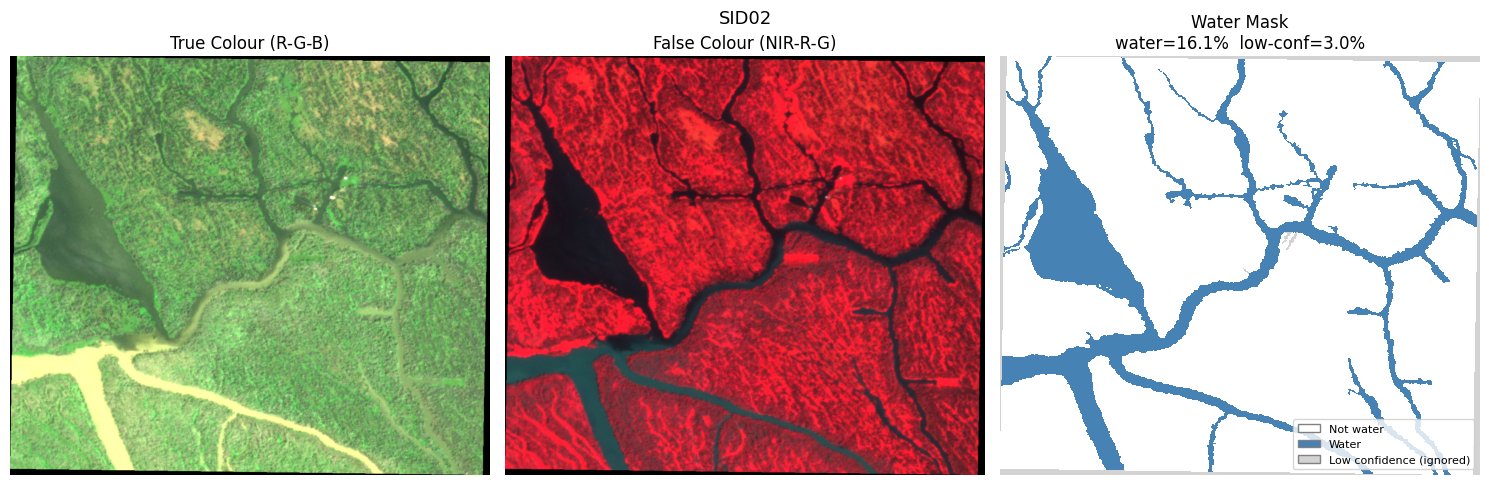

In [7]:
def visualize_sample(img_path: Path, mask_path: Path):
    """Display true-colour, false-colour, and 3-class water mask."""
    img      = rxr.open_rasterio(img_path).values.astype(np.float32)
    raw_mask = rxr.open_rasterio(mask_path).values.squeeze()
    mask     = preprocess_mask(raw_mask.astype(np.uint8))

    def stretch(arr):
        p2, p98 = np.nanpercentile(arr, (2, 98))
        return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

    rgb = stretch(img[[3, 2, 1]].transpose(1, 2, 0))   # R-G-B
    fc  = stretch(img[[5, 3, 2]].transpose(1, 2, 0))   # NIR-R-G

    cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])
    display_mask = np.where(mask == 255, 2, mask)

    valid      = mask != 255
    water_pct  = (mask[valid] == 1).sum() / valid.sum() * 100 if valid.any() else 0.0
    ignore_pct = (mask == 255).sum() / mask.size * 100

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb);  axes[0].set_title("True Colour (R-G-B)");     axes[0].axis("off")
    axes[1].imshow(fc);   axes[1].set_title("False Colour (NIR-R-G)");  axes[1].axis("off")
    axes[2].imshow(display_mask, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[2].set_title(f"Water Mask\nwater={water_pct:.1f}%  low-conf={ignore_pct:.1f}%")
    axes[2].axis("off")
    legend_elements = [
        Patch(facecolor="white",     edgecolor="grey", label="Not water"),
        Patch(facecolor="steelblue", edgecolor="grey", label="Water"),
        Patch(facecolor="lightgrey", edgecolor="grey", label="Low confidence (ignored)"),
    ]
    axes[2].legend(handles=legend_elements, loc="lower right", fontsize=8, framealpha=0.8)
    plt.suptitle(img_path.stem, fontsize=13)
    plt.tight_layout()
    plt.show()

if pairs:
    visualize_sample(*pairs[0])

---
## 3. Tiling

Each scene is tiled into `CHIP_SIZE × CHIP_SIZE` chips. The train/val/test split is performed at the **scene level** to prevent spatial leakage.

In [8]:
def build_chip_index(pairs, chip_size=256, stride=None):
    """Build flat list of (scene_index, row_off, col_off) tuples."""
    if stride is None:
        stride = chip_size
    chips = []
    for i, (img_path, _) in enumerate(pairs):
        with rasterio.open(img_path) as src:
            H, W = src.height, src.width
        for r in range(0, H - chip_size + 1, stride):
            for c in range(0, W - chip_size + 1, stride):
                chips.append((i, r, c))
    print(f"Total chips: {len(chips)}  ({len(pairs)} scenes × ~{len(chips)//max(1,len(pairs))} chips/scene)")
    return chips

chip_index = build_chip_index(pairs, chip_size=CHIP_SIZE)

Total chips: 976  (81 scenes × ~12 chips/scene)


---
## 4. Dataset & DataLoaders

In [9]:
def load_chip(path, row, col, chip_size, band_indices=None):
    """Read a spatial chip from a raster. Optionally subset bands."""
    window = Window(col, row, chip_size, chip_size)
    with rasterio.open(path) as src:
        data = src.read(
            [b + 1 for b in band_indices] if band_indices is not None else None,
            window=window
        )
    return data.astype(np.float32)


class WaterBodyDataset(Dataset):
    """
    PyTorch Dataset for the Mukherjee 2024 PlanetScope water body dataset.
    Returns:
        image : FloatTensor (C, H, W)  — normalised input stack
        mask  : LongTensor  (H, W)     — 0=not-water, 1=water, 255=ignored
    """
    def __init__(self, pairs, chip_index, spectral_bands,
                 dem_dir=None, use_slope=False, use_hillshade=False,
                 chip_size=256, transform=None):
        self.pairs          = pairs
        self.chip_index     = chip_index
        self.spectral_bands = spectral_bands
        self.dem_dir        = Path(dem_dir) if dem_dir else None
        self.use_slope      = use_slope
        self.use_hillshade  = use_hillshade
        self.chip_size      = chip_size
        self.transform      = transform
        self._stats         = None

    def __len__(self):
        return len(self.chip_index)

    def _get_raw(self, idx):
        pair_i, row, col = self.chip_index[idx]
        img_path, mask_path = self.pairs[pair_i]
        spec = load_chip(img_path, row, col, self.chip_size, self.spectral_bands)
        aux = []
        if self.dem_dir and (self.use_slope or self.use_hillshade):
            dem_path = self.dem_dir / img_path.name
            if dem_path.exists():
                dem_bands = ([0] if self.use_slope else []) + ([1] if self.use_hillshade else [])
                aux.append(load_chip(dem_path, row, col, self.chip_size, dem_bands))
        image = np.concatenate([spec] + aux, axis=0) if aux else spec
        mask  = load_chip(mask_path, row, col, self.chip_size).squeeze(0)
        return image, mask

    def compute_stats(self, n_samples=200):
        """Estimate per-channel mean and std from a random subset (NaN-safe)."""
        print("Computing normalisation statistics...")
        indices  = np.random.choice(len(self), min(n_samples, len(self)), replace=False)
        all_data = [self._get_raw(i)[0].reshape(self._get_raw(i)[0].shape[0], -1)
                    for i in tqdm(indices)]
        all_data = np.concatenate(all_data, axis=1)
        mean = np.nanmean(all_data, axis=1)
        std  = np.nanstd(all_data,  axis=1) + 1e-6
        self._stats = (mean, std)
        print(f"  mean: {np.round(mean, 3)}")
        print(f"  std:  {np.round(std,  3)}")
        return mean, std

    def __getitem__(self, idx):
        image, mask = self._get_raw(idx)
        mask = preprocess_mask(mask.astype(np.uint8))
        if self._stats is not None:
            mean, std = self._stats
            image = (image - mean[:, None, None]) / std[:, None, None]
        image = np.nan_to_num(image, nan=0.0, posinf=1.0, neginf=-1.0)
        if self.transform:
            aug   = self.transform(image=image.transpose(1, 2, 0),
                                   mask=mask.astype(np.float32))
            image = aug["image"]
            mask  = aug["mask"].long()
        else:
            image = torch.from_numpy(image)
            mask  = torch.from_numpy(mask.astype(np.int64))
        return image, mask

In [10]:
# ── Augmentation ─────────────────────────────────────────────────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    ToTensorV2()
])
val_transform = A.Compose([ToTensorV2()])

# ── Scene-level split with pinned test scenes ─────────────────────────────────
def find_scene_index(pairs, scene_id):
    for i, (img_path, _) in enumerate(pairs):
        if scene_id.lower() in img_path.stem.lower():
            return i
    raise ValueError(f"Scene '{scene_id}' not found. "
                     f"Available: {[p[0].stem for p in pairs]}")

pinned_test_indices = set()
for sid in PINNED_TEST_SCENES:
    idx = find_scene_index(pairs, sid)
    pinned_test_indices.add(idx)
    print(f"Pinned to test: {pairs[idx][0].name}")

remaining    = [i for i in range(len(pairs)) if i not in pinned_test_indices]
random.shuffle(remaining)
n_extra_test = N_TEST_SCENES - len(pinned_test_indices)

test_scene_idx  = pinned_test_indices | set(remaining[:n_extra_test])
val_scene_idx   = set(remaining[n_extra_test:n_extra_test + N_VAL_SCENES])
train_scene_idx = set(remaining[n_extra_test + N_VAL_SCENES:])

print(f"\nScene split — train: {len(train_scene_idx)}  val: {len(val_scene_idx)}  test: {len(test_scene_idx)}")

train_chips = [c for c in chip_index if c[0] in train_scene_idx]
val_chips   = [c for c in chip_index if c[0] in val_scene_idx]
test_chips  = [c for c in chip_index if c[0] in test_scene_idx]

print(f"Chip split  — train: {len(train_chips)}  val: {len(val_chips)}  test: {len(test_chips)}")
print("\nTest scenes:")
for i in sorted(test_scene_idx):
    flag = " ← pinned" if i in pinned_test_indices else ""
    print(f"  {pairs[i][0].name}{flag}")

# ── Build datasets ────────────────────────────────────────────────────────────
dem_dir_arg = DEM_DIR if (USE_DEM_SLOPE or USE_DEM_HILLSHADE) else None

train_ds = WaterBodyDataset(pairs, train_chips, SPECTRAL_BANDS,
    dem_dir=dem_dir_arg, use_slope=USE_DEM_SLOPE, use_hillshade=USE_DEM_HILLSHADE,
    chip_size=CHIP_SIZE, transform=train_transform)
val_ds   = WaterBodyDataset(pairs, val_chips,   SPECTRAL_BANDS,
    dem_dir=dem_dir_arg, use_slope=USE_DEM_SLOPE, use_hillshade=USE_DEM_HILLSHADE,
    chip_size=CHIP_SIZE, transform=val_transform)
test_ds  = WaterBodyDataset(pairs, test_chips,  SPECTRAL_BANDS,
    dem_dir=dem_dir_arg, use_slope=USE_DEM_SLOPE, use_hillshade=USE_DEM_HILLSHADE,
    chip_size=CHIP_SIZE, transform=val_transform)

mean, std = train_ds.compute_stats(n_samples=200)
val_ds._stats  = (mean, std)
test_ds._stats = (mean, std)

# num_workers>0 works on Colab Linux; pin_memory speeds up GPU transfer
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

Pinned to test: SID78.tif

Scene split — train: 65  val: 8  test: 8
Chip split  — train: 780  val: 89  test: 107

Test scenes:
  SID10.tif
  SID27.tif
  SID40.tif
  SID59.tif
  SID60.tif
  SID65.tif
  SID73.tif
  SID78.tif ← pinned
Computing normalisation statistics...


  0%|          | 0/200 [00:00<?, ?it/s]

  mean: [ 0.377 -0.346  0.266  0.045]
  std:  [0.379 0.411 0.279 0.437]


---
## 5. UNet Architecture

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=10, out_channels=2, encoder_chn=None):
        super().__init__()
        if encoder_chn is None:
            encoder_chn = [16, 32, 64, 128]
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        prev = in_channels
        for ch in encoder_chn:
            self.encoders.append(DoubleConv(prev, ch))
            self.pools.append(nn.MaxPool2d(2))
            prev = ch
        self.bottleneck = DoubleConv(prev, prev * 2)
        prev = prev * 2
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        for ch in reversed(encoder_chn):
            self.upconvs.append(nn.ConvTranspose2d(prev, ch, 2, stride=2))
            self.decoders.append(DoubleConv(ch * 2, ch))
            prev = ch
        self.output_conv = nn.Conv2d(prev, out_channels, 1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x); skips.append(x); x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape != skip.shape:
                x = F.pad(x, [0, skip.shape[3]-x.shape[3], 0, skip.shape[2]-x.shape[2]])
            x = dec(torch.cat([skip, x], dim=1))
        return self.output_conv(x)


model = UNet(in_channels=N_CHANNELS, out_channels=2,
             encoder_chn=ENCODER_CHANNELS).to(DEVICE)
summary(model, input_size=(BATCH_SIZE, N_CHANNELS, CHIP_SIZE, CHIP_SIZE), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
UNet                                     [16, 2, 256, 256]         --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-1                   [16, 16, 256, 256]        --
│    │    └─Sequential: 3-1              [16, 16, 256, 256]        2,944
├─ModuleList: 1-8                        --                        --
│    └─MaxPool2d: 2-2                    [16, 16, 128, 128]        --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-3                   [16, 32, 128, 128]        --
│    │    └─Sequential: 3-2              [16, 32, 128, 128]        13,952
├─ModuleList: 1-8                        --                        --
│    └─MaxPool2d: 2-4                    [16, 32, 64, 64]          --
├─ModuleList: 1-7                        --                        (recursive)
│    └─DoubleConv: 2-5                   [16, 64, 6

---
## 6. Loss Function

In [12]:
def estimate_class_weights(dataset, n_samples=100):
    water_px, total_px = 0, 0
    indices = np.random.choice(len(dataset), min(n_samples, len(dataset)), replace=False)
    for i in indices:
        _, mask = dataset._get_raw(i)
        mask    = preprocess_mask(mask.astype(np.uint8))
        valid   = mask != 255
        water_px += (mask[valid] == 1).sum()
        total_px += valid.sum()
    water_frac = water_px / total_px
    print(f"Estimated water fraction: {water_frac*100:.2f}%")
    w_water    = 1.0 / (water_frac + 1e-6)
    w_nonwater = 1.0 / (1.0 - water_frac + 1e-6)
    total      = w_water + w_nonwater
    weights    = torch.tensor([w_nonwater/total*2, w_water/total*2], dtype=torch.float32)
    print(f"Class weights — non-water: {weights[0]:.3f}, water: {weights[1]:.3f}")
    return weights


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        valid      = targets != 255
        probs      = torch.softmax(logits, dim=1)[:, 1][valid]
        targets_f  = targets[valid].float()
        intersect  = (probs * targets_f).sum()
        return 1.0 - (2.*intersect + self.smooth) / (probs.sum() + targets_f.sum() + self.smooth)


class CombinedLoss(nn.Module):
    def __init__(self, class_weights, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce      = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        self.dice    = DiceLoss()
        self.ce_w    = ce_weight
        self.dice_w  = dice_weight
    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


class_weights = estimate_class_weights(train_ds)
criterion     = CombinedLoss(class_weights.to(DEVICE))

Estimated water fraction: 27.77%
Class weights — non-water: 0.555, water: 1.445


---
## 7. Training

Checkpoints are saved to Google Drive after every epoch so training survives session disconnections.

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

iou_metric = torchmetrics.JaccardIndex(task="binary", ignore_index=255).to(DEVICE)
f1_metric  = torchmetrics.F1Score(task="binary",      ignore_index=255).to(DEVICE)

# ── Resume from checkpoint if available ───────────────────────────────────────
start_epoch    = 1
best_val_loss  = float("inf")
history        = {"train_loss": [], "val_loss": [], "train_iou": [],
                  "val_iou": [], "train_f1": [], "val_f1": []}

resume_path = CHECKPOINT_DIR / "latest_checkpoint.pt"
stats_path  = CHECKPOINT_DIR / "norm_stats.npy"

if RESUME_IF_CHECKPOINT_EXISTS and resume_path.exists():
    ckpt = torch.load(resume_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch   = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    history       = ckpt["history"]

    # Load normalisation stats
    if stats_path.exists():
        stats = np.load(stats_path, allow_pickle=True).item()
        mean, std = stats["mean"], stats["std"]
        val_ds._stats  = (mean, std)
        test_ds._stats = (mean, std)
        print(f"Resumed from epoch {ckpt['epoch']}  (best val loss: {best_val_loss:.4f})")
    else:
        print("Warning: norm_stats.npy not found — recompute stats before training")
else:
    print("Starting training from scratch")


def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    iou_metric.reset(); f1_metric.reset()
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss   = criterion(logits, masks)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            iou_metric.update(preds, masks)
            f1_metric.update(preds, masks)
    return total_loss / len(loader), iou_metric.compute().item(), f1_metric.compute().item()


print(f"Training epochs {start_epoch}–{NUM_EPOCHS} on {DEVICE}\n")
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    tr_loss, tr_iou, tr_f1 = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_iou, vl_f1 = run_epoch(val_loader,   model, criterion)
    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    for k, v in zip(["train_loss","val_loss","train_iou","val_iou","train_f1","val_f1"],
                    [tr_loss, vl_loss, tr_iou, vl_iou, tr_f1, vl_f1]):
        history[k].append(v)

    # Save best model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pt")

    # Save resumable checkpoint every epoch
    torch.save({
        "epoch":         epoch,
        "model":         model.state_dict(),
        "optimizer":     optimizer.state_dict(),
        "scheduler":     scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "history":       history,
    }, resume_path)

    # Save normalisation stats separately as numpy (not inside torch checkpoint)
    np.save(CHECKPOINT_DIR / "norm_stats.npy", {"mean": mean, "std": std})

    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} "
          f"| train loss {tr_loss:.4f}  IoU {tr_iou:.3f}  F1 {tr_f1:.3f} "
          f"| val loss {vl_loss:.4f}  IoU {vl_iou:.3f}  F1 {vl_f1:.3f} "
          f"| lr {current_lr:.2e}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Resumed from epoch 50  (best val loss: 0.1661)
Training epochs 51–50 on cuda


Best val loss: 0.1661


---
## 8. Training Curves

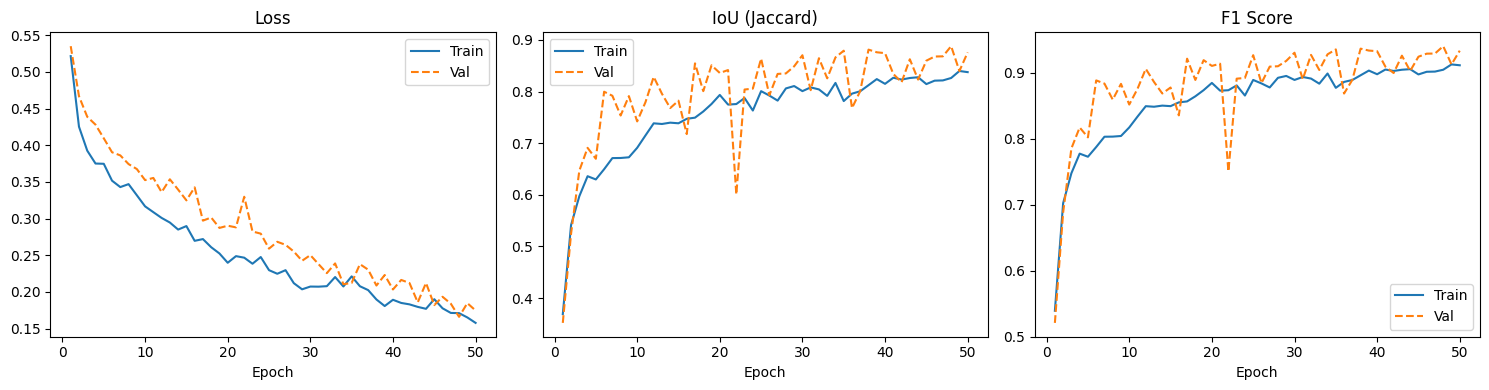

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history["train_loss"]) + 1)
for ax, metric in zip(axes, ["loss", "iou", "f1"]):
    ax.plot(epochs, history[f"train_{metric}"], label="Train")
    ax.plot(epochs, history[f"val_{metric}"],   label="Val", linestyle="--")
    ax.set_title({"loss":"Loss","iou":"IoU (Jaccard)","f1":"F1 Score"}[metric])
    ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "training_curves.png", dpi=150)
plt.show()

---
## 9. Test Evaluation

In [19]:
# Load normalisation stats from checkpoint if resuming in a fresh session
if stats_path.exists():
    stats = np.load(stats_path, allow_pickle=True).item()
    mean, std = stats["mean"], stats["std"]
    test_ds._stats = (mean, std)

model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pt", map_location=DEVICE))

precision_m = torchmetrics.Precision(task="binary", ignore_index=255).to(DEVICE)
recall_m    = torchmetrics.Recall(task="binary",    ignore_index=255).to(DEVICE)
iou_metric.reset(); f1_metric.reset()

model.eval()
test_loss = 0.0
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Test"):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        logits = model(images)
        test_loss += criterion(logits, masks).item()
        preds = logits.argmax(dim=1)
        iou_metric.update(preds, masks); f1_metric.update(preds, masks)
        precision_m.update(preds, masks); recall_m.update(preds, masks)

print("\n── Test Results ───────────────────────────────")
print(f"  Loss      : {test_loss/len(test_loader):.4f}")
print(f"  IoU       : {iou_metric.compute().item():.4f}")
print(f"  F1        : {f1_metric.compute().item():.4f}")
print(f"  Precision : {precision_m.compute().item():.4f}")
print(f"  Recall    : {recall_m.compute().item():.4f}")

Test:   0%|          | 0/7 [00:00<?, ?it/s]


── Test Results ───────────────────────────────
  Loss      : 0.1290
  IoU       : 0.8775
  F1        : 0.9348
  Precision : 0.9755
  Recall    : 0.8973


---
## 10. Qualitative Predictions

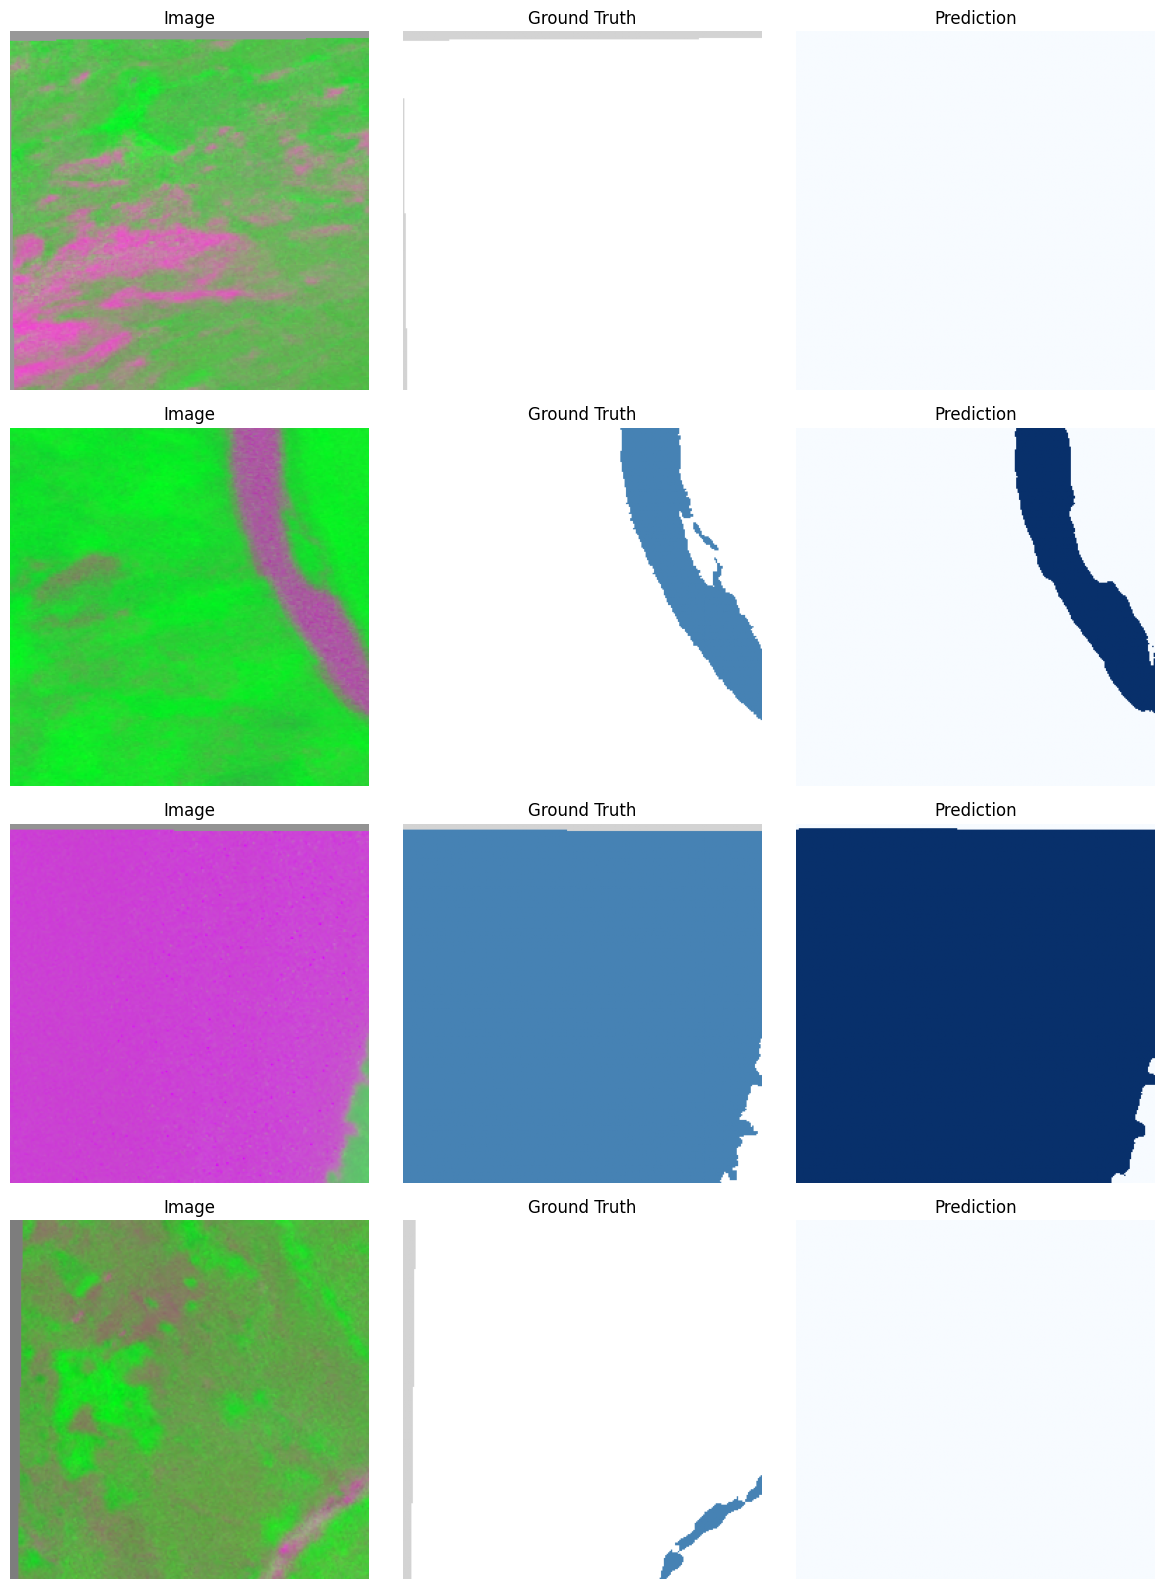

In [20]:
def visualize_predictions(dataset, model, n=4, device=DEVICE):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    if n == 1: axes = axes[np.newaxis, :]
    for row_i, idx in enumerate(indices):
        image, mask = dataset[idx]
        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).squeeze().cpu().numpy()
        rgb = image[[3,2,1]].numpy().transpose(1,2,0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
        display_mask = np.where(mask.numpy() == 255, 2, mask.numpy())
        cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])
        axes[row_i,0].imshow(rgb);  axes[row_i,0].set_title("Image");        axes[row_i,0].axis("off")
        axes[row_i,1].imshow(display_mask, cmap=cmap, vmin=0, vmax=2)
        axes[row_i,1].set_title("Ground Truth");  axes[row_i,1].axis("off")
        axes[row_i,2].imshow(pred, cmap="Blues", vmin=0, vmax=1)
        axes[row_i,2].set_title("Prediction");    axes[row_i,2].axis("off")
    plt.tight_layout(); plt.show()

visualize_predictions(test_ds, model, n=4)

---
## 11. Full Scene Inference

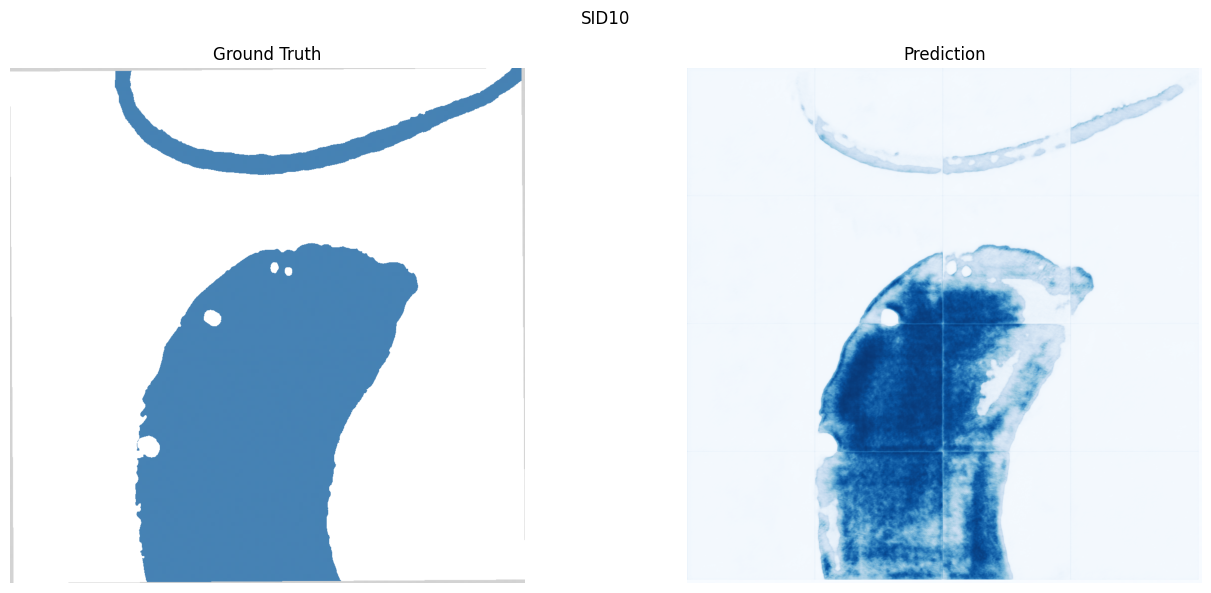

ValueError: Given nodata value, nan, is beyond the valid range of its data type, uint8.

In [35]:
def predict_full_scene(img_path, model, spectral_bands, mean, std,
                       chip_size=256, device=DEVICE,
                       dem_path=None, use_slope=False, use_hillshade=False):
    model.eval()
    with rasterio.open(img_path) as src:
        H, W = src.height, src.width
    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.uint8)
    for r in range(0, H - chip_size + 1, chip_size):
        for c in range(0, W - chip_size + 1, chip_size):
            spec = load_chip(img_path, r, c, chip_size, spectral_bands)
            aux  = []
            if dem_path and (use_slope or use_hillshade):
                dem_bands = ([0] if use_slope else []) + ([1] if use_hillshade else [])
                aux.append(load_chip(dem_path, r, c, chip_size, dem_bands))
            image = np.concatenate([spec] + aux, axis=0) if aux else spec
            image = (image - mean[:, None, None]) / std[:, None, None]
            image = np.nan_to_num(image, nan=0.0, posinf=1.0, neginf=-1.0)
            tensor = torch.from_numpy(image).unsqueeze(0).to(device)
            with torch.no_grad():
                prob = torch.softmax(model(tensor), dim=1)[0, 1].cpu().numpy()
            prob_map[r:r+chip_size, c:c+chip_size]  += prob
            count_map[r:r+chip_size, c:c+chip_size] += 1
    return (prob_map / np.maximum(count_map, 1))#.astype(np.uint8)
    # return (prob_map / np.maximum(count_map, 1) > 0.5).astype(np.uint8)

def save_prediction_geotiff(pred_array, reference_path, output_path):
    with rasterio.open(reference_path) as src:
        profile = src.profile.copy()
    profile.update(count=1, dtype="uint8", compress="lzw")
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(pred_array[np.newaxis, ...])
    print(f"Saved: {output_path}")


# Run on first pinned test scene (SID78)
test_scene_list = [pairs[i] for i in sorted(test_scene_idx)]
sample_img_path, sample_mask_path = test_scene_list[0]
dem_path_arg = (DEM_DIR / sample_img_path.name) if dem_dir_arg else None

pred = predict_full_scene(
    sample_img_path, model, SPECTRAL_BANDS, mean, std,
    chip_size=CHIP_SIZE, device=DEVICE,
    dem_path=dem_path_arg, use_slope=USE_DEM_SLOPE, use_hillshade=USE_DEM_HILLSHADE
)

raw_gt  = rxr.open_rasterio(sample_mask_path).values.squeeze()
gt_disp = np.where(preprocess_mask(raw_gt.astype(np.uint8)) == 255, 2,
                   preprocess_mask(raw_gt.astype(np.uint8)))
cmap    = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(gt_disp, cmap=cmap, vmin=0, vmax=2)
axes[0].set_title("Ground Truth"); axes[0].axis("off")
axes[1].imshow(pred, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Prediction");   axes[1].axis("off")
plt.suptitle(sample_img_path.stem); plt.tight_layout(); plt.show()

out_path = CHECKPOINT_DIR / f"{sample_img_path.stem}_pred.tif"
save_prediction_geotiff(pred, sample_img_path, out_path)

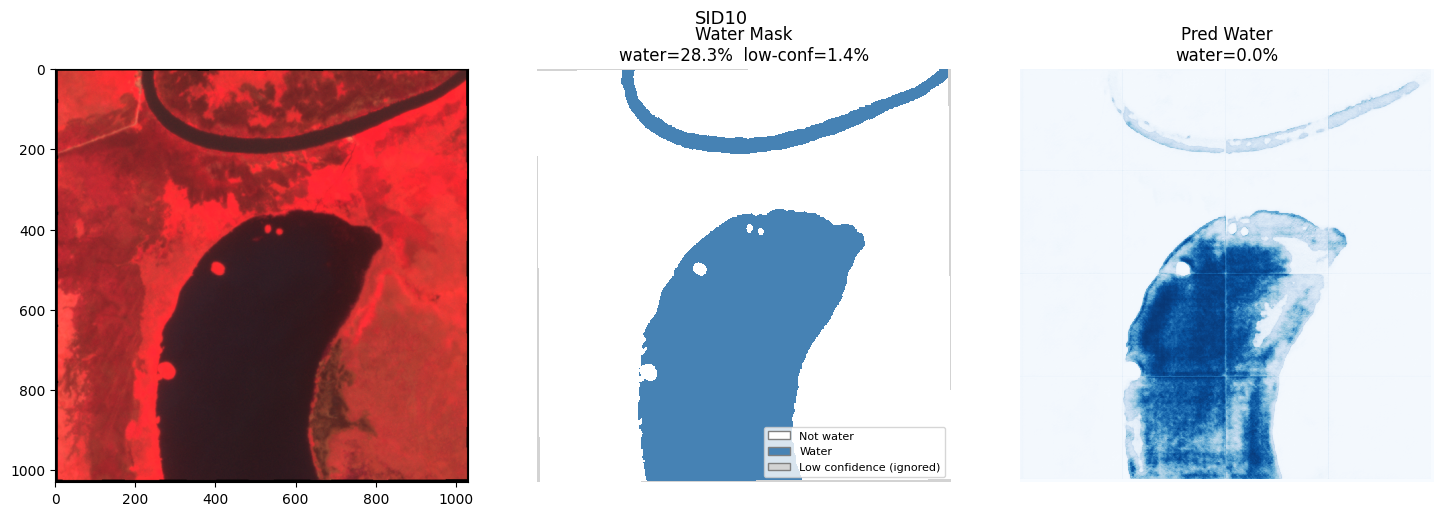

In [37]:
def plot_pred_scene(img_path:Path, mask_path:Path, pred):
    img      = rxr.open_rasterio(img_path).values.astype(np.float32)
    raw_mask = rxr.open_rasterio(mask_path).values.squeeze()
    mask     = preprocess_mask(raw_mask.astype(np.uint8))

    def stretch(arr):
        p2, p98 = np.nanpercentile(arr, (2, 98))
        return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

    # rgb = stretch(img[[3, 2, 1]].transpose(1, 2, 0))   # R-G-B
    fc  = stretch(img[[5, 3, 2]].transpose(1, 2, 0))   # NIR-R-G

    cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])
    display_mask = np.where(mask == 255, 2, mask)

    # from hand labeled
    valid      = mask != 255
    water_pct  = (mask[valid] == 1).sum() / valid.sum() * 100 if valid.any() else 0.0
    ignore_pct = (mask == 255).sum() / mask.size * 100

    # from prediction
    # valid      = mask != 255
    pred_water_pct  = (pred[valid] == 1).sum() / valid.sum() * 100 if valid.any() else 0.0
    # ignore_pct = (mask == 255).sum() / mask.size * 100

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # axes[0].imshow(rgb);  axes[0].set_title("True Colour (R-G-B)");     axes[0].axis("off")
    axes[0].imshow(fc);   axes[1].set_title("False Colour (NIR-R-G)");  axes[1].axis("off")

    axes[1].imshow(display_mask, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
    axes[1].set_title(f"Water Mask\nwater={water_pct:.1f}%  low-conf={ignore_pct:.1f}%")
    axes[1].axis("off")
    legend_elements = [
        Patch(facecolor="white",     edgecolor="grey", label="Not water"),
        Patch(facecolor="steelblue", edgecolor="grey", label="Water"),
        Patch(facecolor="lightgrey", edgecolor="grey", label="Low confidence (ignored)"),
    ]
    axes[1].legend(handles=legend_elements, loc="lower right", fontsize=8, framealpha=0.8)

    axes[2].imshow(pred, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    axes[2].set_title(f"Pred Water\nwater={pred_water_pct:.1f}%")
    axes[2].axis("off")
    # legend_elements = [
    #     Patch(facecolor="white",     edgecolor="grey", label="Not water"),
    #     Patch(facecolor="blue", edgecolor="grey", label="Water"),
    #     # Patch(facecolor="lightgrey", edgecolor="grey", label="Low confidence (ignored)"),
    # ]
    # axes[2].legend(handles=legend_elements, loc="lower right", fontsize=8, framealpha=0.8)

    plt.suptitle(img_path.stem, fontsize=13)
    plt.tight_layout()
    plt.show()



# test_scene_list = [pairs[i] for i in sorted(test_scene_idx)]
# sample_img_path, sample_mask_path = test_scene_list[0]
# dem_path_arg = (DEM_DIR / sample_img_path.name) if dem_dir_arg else None

plot_pred_scene(sample_img_path, sample_mask_path, pred)


## 11.5 Run Inferrence on NC data

In [43]:
NC_pred = predict_full_scene(
    DRIVE_ROOT / "data/NC-PS/20240118_150740_48_24c9_3B_AnalyticMS_SR_8b_bandmath.tif",
    model,
    SPECTRAL_BANDS,
    mean, std,
    chip_size=CHIP_SIZE,
    device=DEVICE,
    dem_path=dem_path_arg, use_slope=USE_DEM_SLOPE, use_hillshade=USE_DEM_HILLSHADE
)

In [ ]:
# def plot_pred_scene(img_path:Path, mask_path:Path, pred):
img_path = DRIVE_ROOT / "data/NC-PS/20240118_150740_48_24c9_3B_AnalyticMS_SR_8b_bandmath.tif"
img      = rxr.open_rasterio(img_path).values.astype(np.float32)
# raw_mask = rxr.open_rasterio(mask_path).values.squeeze()
# mask     = preprocess_mask(raw_mask.astype(np.uint8))

def stretch(arr):
    p2, p98 = np.nanpercentile(arr, (2, 98))
    return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

rgb = stretch(img[[3, 2, 1]].transpose(1, 2, 0))   # R-G-B
fc  = stretch(img[[5, 3, 2]].transpose(1, 2, 0))   # NIR-R-G

# cmap = mcolors.ListedColormap(["white", "steelblue", "lightgrey"])
# display_mask = np.where(mask == 255, 2, mask)

# # from hand labeled
# valid      = mask != 255
# water_pct  = (mask[valid] == 1).sum() / valid.sum() * 100 if valid.any() else 0.0
# ignore_pct = (mask == 255).sum() / mask.size * 100

# from prediction
# valid      = mask != 255
# pred_water_pct  = (pred[valid] == 1).sum() / valid.sum() * 100 if valid.any() else 0.0
# ignore_pct = (mask == 255).sum() / mask.size * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb);  axes[0].set_title("True Colour (R-G-B)");     axes[0].axis("off")
axes[1].imshow(fc);   axes[1].set_title("False Colour (NIR-R-G)");  axes[1].axis("off")

axes[2].imshow(NC_pred, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title(f"Pred Water") #\nwater={pred_water_pct:.1f}%")
axes[2].axis("off")

plt.suptitle(img_path.stem, fontsize=13)
plt.tight_layout()
plt.show()


---
## 12. Experiment Tracking

In [39]:
import pandas as pd

log_path = CHECKPOINT_DIR / "experiment_log.csv"

def log_experiment(name, n_channels, use_slope, use_hillshade, spectral_bands,
                   test_iou, test_f1, test_precision, test_recall, notes=""):
    row = {
        "name": name, "n_channels": n_channels,
        "use_slope": use_slope, "use_hillshade": use_hillshade,
        "spectral_bands": str(spectral_bands),
        "test_iou": round(test_iou, 4), "test_f1": round(test_f1, 4),
        "test_precision": round(test_precision, 4), "test_recall": round(test_recall, 4),
        "notes": notes,
    }
    df = pd.concat([pd.read_csv(log_path), pd.DataFrame([row])], ignore_index=True) \
         if log_path.exists() else pd.DataFrame([row])
    df.to_csv(log_path, index=False)
    print(f"Logged: {name}")
    return df

log_experiment(
    name="baseline_indices_only",
    n_channels=N_CHANNELS, use_slope=USE_DEM_SLOPE, use_hillshade=USE_DEM_HILLSHADE,
    spectral_bands=SPECTRAL_BANDS,
    test_iou=iou_metric.compute().item(), test_f1=f1_metric.compute().item(),
    test_precision=precision_m.compute().item(), test_recall=recall_m.compute().item(),
    notes="Indices only [6,7,8,9], 50 epochs, T4 GPU"
)
print("Uncomment the log_experiment call above after your first test run.")

Logged: baseline_indices_only
Uncomment the log_experiment call above after your first test run.


---
## Suggested Experiments

| Experiment | `SPECTRAL_BANDS` | `USE_DEM_SLOPE` | Expected outcome |
|---|---|---|---|
| Indices only | `[6,7,8,9]` | False | Clean cross-dataset baseline |
| All bands | `list(range(10))` | False | Tests whether raw spectral adds signal |
| Indices + slope | `[6,7,8,9]` | True | Tests DEM contribution |
| All bands + slope | `list(range(10))` | True | Max feature set |

The experiment log is saved to Google Drive and persists across sessions.